# 📈 Módulo 4: Regressão
## Objetivos de Aprendizagem
- Implementar Regressão Linear com OLS e diagnosticar resíduos
- Aplicar regularização com Ridge (L2), LASSO (L1) e Elastic Net
- Visualizar os caminhos de regularização dos coeficientes
- Comparar GLMs e GAMs para dados não-gaussianos
- Avaliar modelos com MSE, R², MAE, RMSE

## 2. Teoria e Equações

### 2.1 Regressão Linear
$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p = X\beta$$

### 2.2 Estimador de Mínimos Quadrados (OLS)
$$\hat{\beta}_{OLS} = (X^T X)^{-1} X^T y$$
Minimiza a soma dos quadrados dos resíduos: $\min_\beta \|y - X\beta\|_2^2$

### 2.3 Funções de Custo e Métricas
$$MSE = \frac{1}{n}\sum_{i=1}^n(y_i - \hat{y}_i)^2 \quad RMSE = \sqrt{MSE}$$
$$MAE = \frac{1}{n}\sum_{i=1}^n|y_i - \hat{y}_i| \quad R^2 = 1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}$$

### 2.4 Ridge Regression (L2)
$$J(\beta) = \underbrace{\sum_{i=1}^n(y_i-\hat{y}_i)^2}_{\text{erro}} + \underbrace{\lambda\sum_{j=1}^p\beta_j^2}_{\text{penalidade L2}}$$
- Solução: $\hat{\beta}_{Ridge} = (X^TX + \lambda I)^{-1}X^Ty$
- Reduz coeficientes mas **nunca os zera**

### 2.5 LASSO Regression (L1)
$$J(\beta) = \sum_{i=1}^n(y_i-\hat{y}_i)^2 + \lambda\sum_{j=1}^p|\beta_j|$$
- **Produz soluções esparsas** (alguns $\beta_j = 0$) → seleção de variáveis automática

### 2.6 Elastic Net
$$J(\beta) = \sum_{i=1}^n(y_i-\hat{y}_i)^2 + \lambda_1\sum_{j=1}^p|\beta_j| + \lambda_2\sum_{j=1}^p\beta_j^2$$
- Combina L1 e L2: útil quando há grupos de features correlacionadas

### 2.7 Comparação das Penalidades
| Método | Penalidade | Esparsidade | Grupos | Multicolinearidade |
|--------|-----------|-------------|--------|-------------------|
| OLS | Nenhuma | Não | Não | Sensível |
| Ridge | L2 ($\beta^2$) | Não | Não | Robusto |
| LASSO | L1 ($|\beta|$) | **Sim** | Não | Seleciona 1 |
| Elastic Net | L1 + L2 | **Sim** | **Sim** | Robusto |

📊 REGRESSÃO LINEAR — COEFICIENTES


,Feature,Coeficiente
1,quartos,54.69
3,distancia_centro,-8.38
0,area,4.96
2,idade,-2.23
4,renda_bairro,1.22



Intercepto: 199.46
R² (treino): 0.9445
R² (teste):  0.9512
RMSE (teste): R$ 77.9 mil


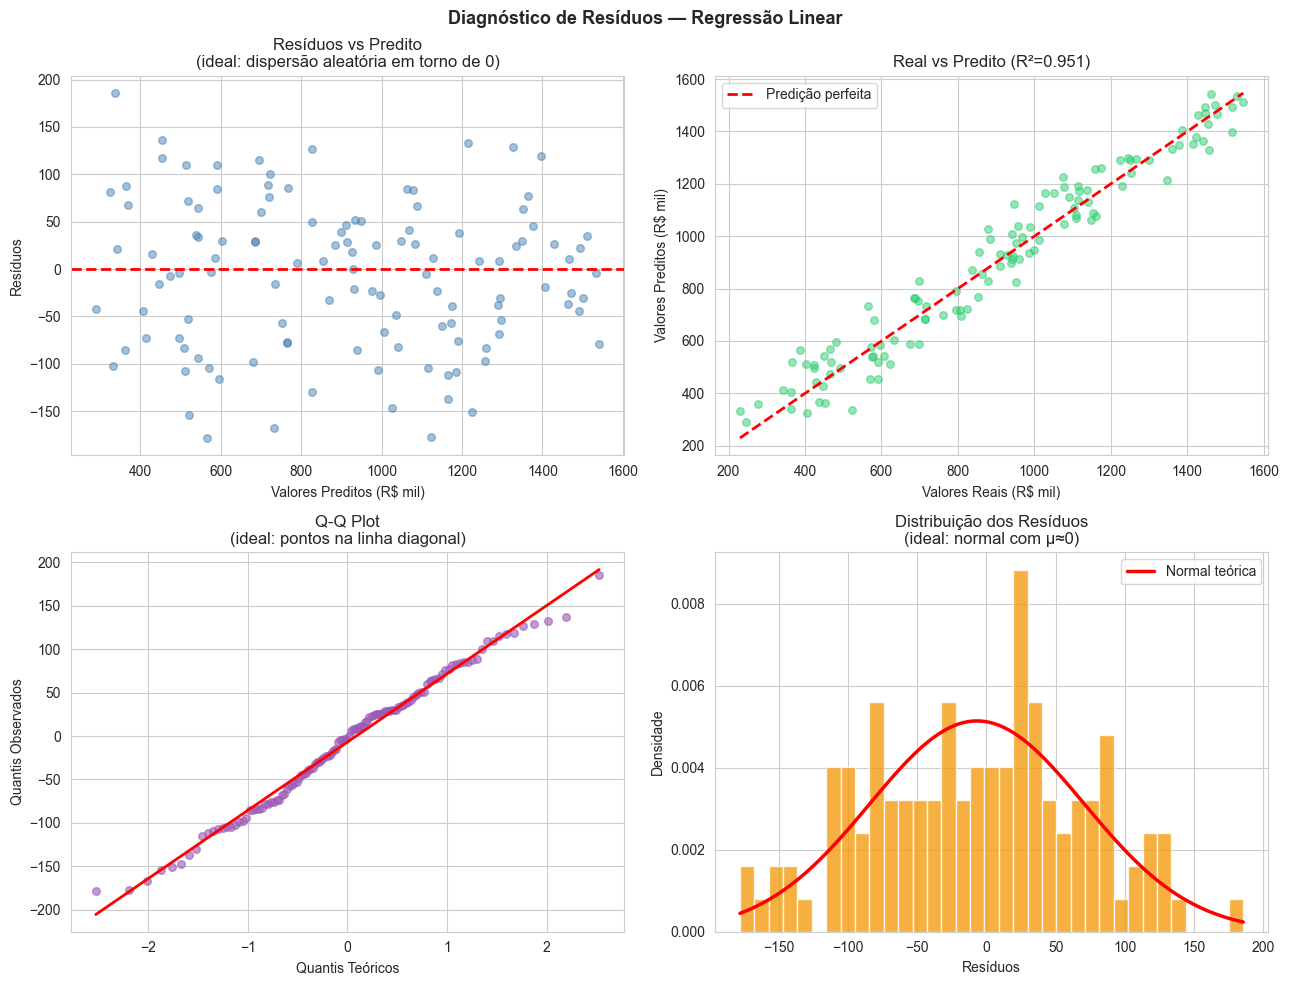

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style("whitegrid")

# Dataset: Previsão de Preço de Imóveis (inspirado no California Housing)
n = 600
area = np.random.uniform(40, 250, n)
quartos = np.random.randint(1, 6, n)
idade = np.random.randint(1, 40, n)
distancia_centro = np.random.uniform(1, 30, n)
renda_bairro = np.random.lognormal(9.5, 0.5, n)

# Preço com relações não-lineares + ruído
preco = (5000 * area + 
         50000 * quartos + 
         -2000 * idade +
         -8000 * distancia_centro + 
         0.8 * renda_bairro +
         np.random.randn(n) * 80000 + 200000)
preco = np.abs(preco) / 1000  # Em R$ mil

df = pd.DataFrame({
    'area': area, 'quartos': quartos, 'idade': idade,
    'distancia_centro': distancia_centro, 'renda_bairro': renda_bairro/1000,
    'preco_mil': preco
})

X = df.drop('preco_mil', axis=1)
y = df['preco_mil']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Regressão Linear OLS
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("=" * 55)
print("📊 REGRESSÃO LINEAR — COEFICIENTES")
print("=" * 55)
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': lr.coef_,
    'Coef_Abs': np.abs(lr.coef_)
}).sort_values('Coef_Abs', ascending=False)
display(coef_df.drop('Coef_Abs', axis=1).round(2))
print(f"\nIntercepto: {lr.intercept_:.2f}")
print(f"R² (treino): {lr.score(X_train, y_train):.4f}")
print(f"R² (teste):  {lr.score(X_test, y_test):.4f}")
print(f"RMSE (teste): R$ {np.sqrt(mean_squared_error(y_test, y_pred)):.1f} mil")

# Diagnóstico de resíduos
residuos = y_test.values - y_pred

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Diagnóstico de Resíduos — Regressão Linear', fontsize=13, fontweight='bold')

axes[0,0].scatter(y_pred, residuos, alpha=0.5, color='steelblue', s=30)
axes[0,0].axhline(0, color='red', lw=2, linestyle='--')
axes[0,0].set_xlabel('Valores Preditos (R$ mil)'); axes[0,0].set_ylabel('Resíduos')
axes[0,0].set_title('Resíduos vs Predito\n(ideal: dispersão aleatória em torno de 0)')

axes[0,1].scatter(y_test, y_pred, alpha=0.5, color='#2ecc71', s=30)
min_val, max_val = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[0,1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predição perfeita')
axes[0,1].set_xlabel('Valores Reais (R$ mil)'); axes[0,1].set_ylabel('Valores Preditos (R$ mil)')
axes[0,1].set_title(f'Real vs Predito (R²={lr.score(X_test,y_test):.3f})')
axes[0,1].legend()

from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist="norm")
axes[1,0].scatter(osm, osr, color='#9b59b6', alpha=0.6, s=30)
axes[1,0].plot(osm, slope*np.array(osm)+intercept, 'r-', lw=2)
axes[1,0].set_xlabel('Quantis Teóricos'); axes[1,0].set_ylabel('Quantis Observados')
axes[1,0].set_title('Q-Q Plot\n(ideal: pontos na linha diagonal)')

axes[1,1].hist(residuos, bins=35, color='#f39c12', edgecolor='white', alpha=0.8, density=True)
mu, sigma = residuos.mean(), residuos.std()
x_range = np.linspace(residuos.min(), residuos.max(), 100)
axes[1,1].plot(x_range, stats.norm.pdf(x_range, mu, sigma), 'r-', lw=2.5, label='Normal teórica')
axes[1,1].set_xlabel('Resíduos'); axes[1,1].set_ylabel('Densidade')
axes[1,1].set_title('Distribuição dos Resíduos\n(ideal: normal com μ≈0)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('../imagens/04_diagnostico_residuos.png', dpi=150, bbox_inches='tight')
plt.show()

🔒 REGULARIZAÇÃO: RIDGE, LASSO E ELASTIC NET


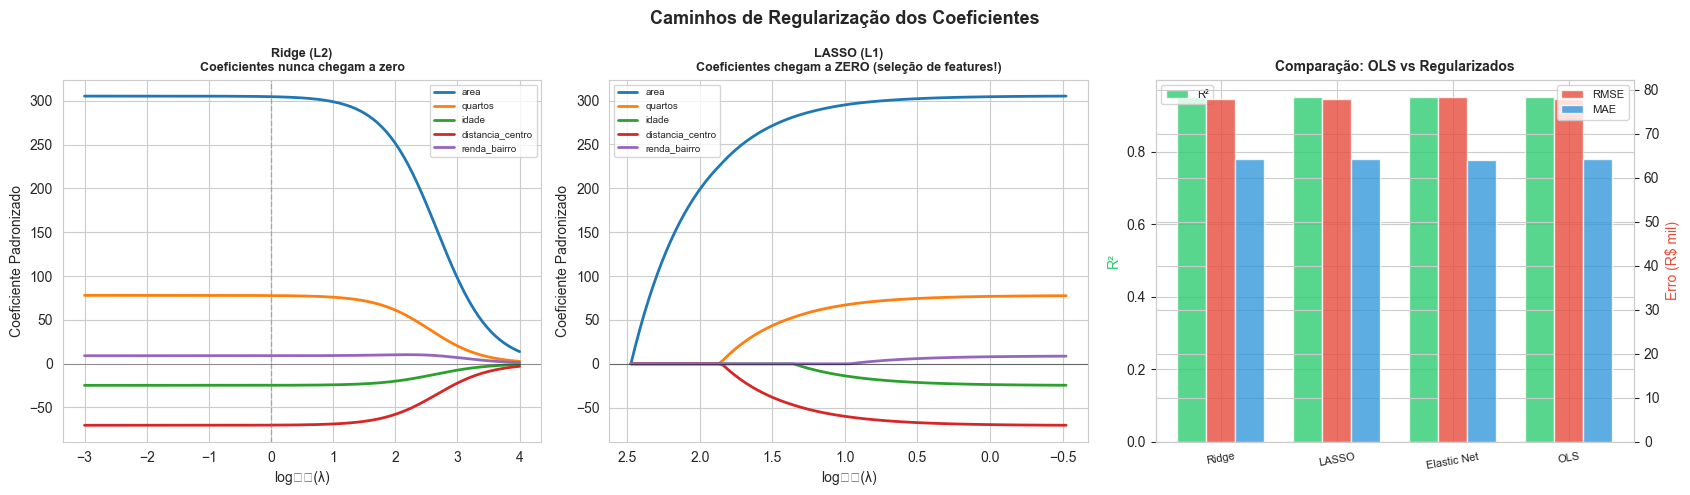


📊 Tabela comparativa:


,R²,RMSE,MAE
Ridge,0.951,77.888,64.194
LASSO,0.951,77.865,64.180
Elastic Net,0.951,78.410,64.071
OLS,0.951,77.894,64.199


In [2]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

print("=" * 55)
print("🔒 REGULARIZAÇÃO: RIDGE, LASSO E ELASTIC NET")
print("=" * 55)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Paths de regularização
alphas = np.logspace(-3, 4, 200)

# Ridge: caminho de coeficientes
from sklearn.linear_model import ridge_regression
coefs_ridge = []
for alpha in alphas:
    coef = ridge_regression(X_train_sc, y_train, alpha=alpha)
    coefs_ridge.append(coef)

# LASSO: path oficial
from sklearn.linear_model import lasso_path
alphas_lasso, coefs_lasso, _ = lasso_path(X_train_sc, y_train)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Caminhos de Regularização dos Coeficientes', fontsize=13, fontweight='bold')

# Ridge path
for i, col in enumerate(X.columns):
    axes[0].plot(np.log10(alphas), [c[i] for c in coefs_ridge], lw=2, label=col)
axes[0].axvline(0, color='gray', lw=1, linestyle='--', alpha=0.5)
axes[0].set_xlabel('log₁₀(λ)'); axes[0].set_ylabel('Coeficiente Padronizado')
axes[0].set_title('Ridge (L2)\nCoeficientes nunca chegam a zero', fontweight='bold', fontsize=9)
axes[0].legend(fontsize=7); axes[0].axhline(0, color='black', lw=0.8, alpha=0.3)

# LASSO path
for i, col in enumerate(X.columns):
    axes[1].plot(np.log10(alphas_lasso + 1e-10), coefs_lasso[i], lw=2, label=col)
axes[1].set_xlabel('log₁₀(λ)'); axes[1].set_ylabel('Coeficiente Padronizado')
axes[1].set_title('LASSO (L1)\nCoeficientes chegam a ZERO (seleção de features!)', fontweight='bold', fontsize=9)
axes[1].legend(fontsize=7); axes[1].axhline(0, color='black', lw=0.8, alpha=0.5)
axes[1].invert_xaxis()

# Comparação de performance
resultados = {}
melhores_alphas = {}

for nome, ModelClass in [('Ridge', Ridge), ('LASSO', Lasso), ('Elastic Net', ElasticNet)]:
    if nome == 'Elastic Net':
        modelo = Pipeline([('scaler', StandardScaler()), ('modelo', ElasticNet(alpha=0.1, l1_ratio=0.5))])
    else:
        modelo = Pipeline([('scaler', StandardScaler()), ('modelo', ModelClass(alpha=0.1))])
    modelo.fit(X_train, y_train)
    y_pred_m = modelo.predict(X_test)
    resultados[nome] = {
        'R²': r2_score(y_test, y_pred_m),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_m)),
        'MAE': mean_absolute_error(y_test, y_pred_m)
    }

resultados['OLS'] = {
    'R²': r2_score(y_test, y_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
    'MAE': mean_absolute_error(y_test, y_pred)
}

df_result = pd.DataFrame(resultados).T.round(3)

x = np.arange(len(df_result))
width = 0.25
bars1 = axes[2].bar(x - width, df_result['R²'], width, label='R²', color='#2ecc71', alpha=0.8)
axes2_twin = axes[2].twinx()
bars2 = axes2_twin.bar(x, df_result['RMSE'], width, label='RMSE', color='#e74c3c', alpha=0.8)
bars3 = axes2_twin.bar(x + width, df_result['MAE'], width, label='MAE', color='#3498db', alpha=0.8)
axes[2].set_xticks(x); axes[2].set_xticklabels(df_result.index, rotation=10, fontsize=8)
axes[2].set_ylabel('R²', color='#2ecc71'); axes2_twin.set_ylabel('Erro (R$ mil)', color='#e74c3c')
axes[2].set_title('Comparação: OLS vs Regularizados', fontweight='bold', fontsize=10)
axes[2].legend(loc='upper left', fontsize=8)
axes2_twin.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('../imagens/04_regularizacao.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Tabela comparativa:")
display(df_result)

📊 GLM — MODELOS LINEARES GENERALIZADOS

Exemplo: Prever número de sinistros (distribuição Poisson)
          Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
const -2.449456  0.689372 -3.553170  0.000381 -3.800601 -1.098312
x1     0.027119  0.012172  2.228029  0.025879  0.003263  0.050976
x2     0.328595  0.068529  4.794965  0.000002  0.194280  0.462910
x3    -0.055225  0.011790 -4.683896  0.000003 -0.078334 -0.032117

Interpretação dos coeficientes (exp(β)):
  Idade: exp(0.027) = 1.027
  → Cada ano a mais de idade multiplica o risco por 1.027


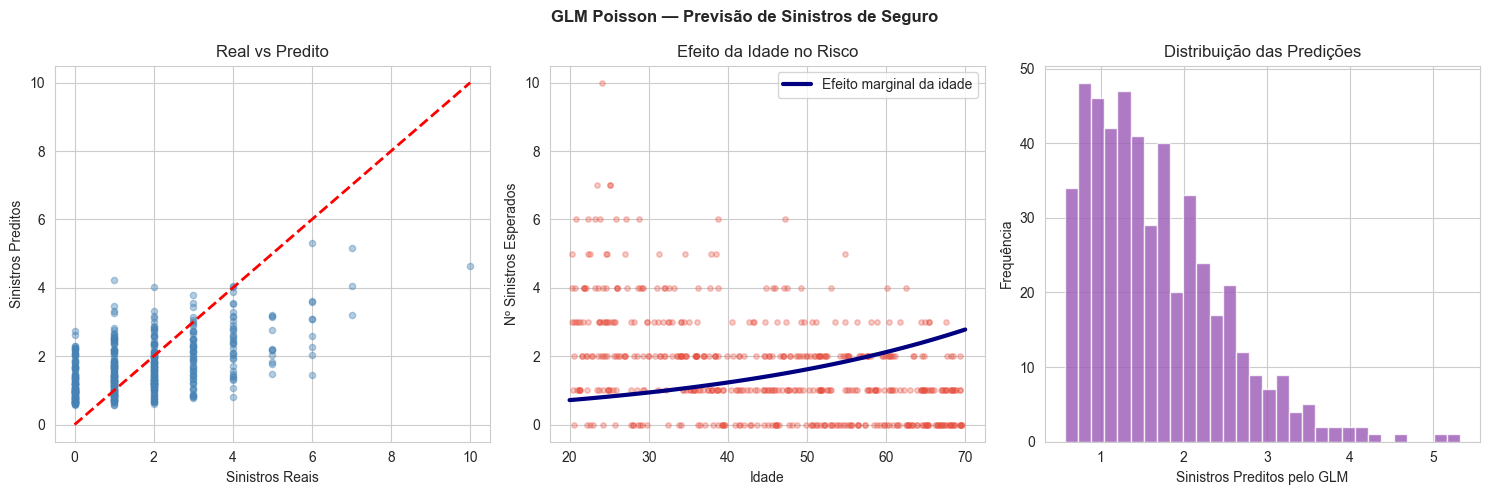

In [3]:
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod import families
import statsmodels.api as sm

print("=" * 55)
print("📊 GLM — MODELOS LINEARES GENERALIZADOS")
print("=" * 55)
print("\nExemplo: Prever número de sinistros (distribuição Poisson)")

# Simular dados de seguros
np.random.seed(42)
n_seguros = 500
idade_seg = np.random.uniform(20, 70, n_seguros)
km_rodados = np.random.lognormal(9.5, 0.5, n_seguros)
anos_habilitacao = np.clip(idade_seg - 18 + np.random.randn(n_seguros)*3, 0.5, 50)

# Número de sinistros (Poisson)
lambda_poisson = np.exp(-2 + 0.02*idade_seg + 0.3*np.log(km_rodados) - 0.05*anos_habilitacao)
n_sinistros = np.random.poisson(lambda_poisson)

X_glm = sm.add_constant(np.column_stack([idade_seg, np.log(km_rodados), anos_habilitacao]))
glm_model = GLM(n_sinistros, X_glm, family=families.Poisson()).fit()

print(glm_model.summary2().tables[1])
print(f"\nInterpretação dos coeficientes (exp(β)):")
print(f"  Idade: exp({glm_model.params[1]:.3f}) = {np.exp(glm_model.params[1]):.3f}")
print(f"  → Cada ano a mais de idade multiplica o risco por {np.exp(glm_model.params[1]):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('GLM Poisson — Previsão de Sinistros de Seguro', fontsize=12, fontweight='bold')

y_pred_glm = glm_model.predict()

axes[0].scatter(n_sinistros, y_pred_glm, alpha=0.4, color='steelblue', s=20)
axes[0].plot([0, n_sinistros.max()], [0, n_sinistros.max()], 'r--', lw=2)
axes[0].set_xlabel('Sinistros Reais'); axes[0].set_ylabel('Sinistros Preditos')
axes[0].set_title('Real vs Predito')

axes[1].scatter(idade_seg, n_sinistros, alpha=0.3, color='#e74c3c', s=15)
idades_range = np.linspace(20, 70, 100)
km_fixo = float(np.median(km_rodados))
anos_fixo = float(np.median(anos_habilitacao))
# Construct prediction matrix manually to guarantee 4 columns matching X_glm
X_pred_range = np.column_stack([
    np.ones(100),
    idades_range,
    np.log(km_fixo) * np.ones(100),
    anos_fixo * np.ones(100)
])
pred_range = GLM(n_sinistros, X_glm, family=families.Poisson()).fit().predict(X_pred_range)
axes[1].plot(idades_range, pred_range, 'navy', lw=3, label='Efeito marginal da idade')
axes[1].set_xlabel('Idade'); axes[1].set_ylabel('Nº Sinistros Esperados')
axes[1].set_title('Efeito da Idade no Risco'); axes[1].legend()

# Distribuição dos valores ajustados
axes[2].hist(y_pred_glm, bins=30, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[2].set_xlabel('Sinistros Preditos pelo GLM'); axes[2].set_ylabel('Frequência')
axes[2].set_title('Distribuição das Predições')

plt.tight_layout()
plt.savefig('../imagens/04_glm_poisson.png', dpi=150, bbox_inches='tight')
plt.show()

🏆 COMPARAÇÃO FINAL DE TODOS OS MODELOS

📊 Resultados (preço em R$ mil):


,R² Teste,RMSE Teste,MAE Teste,R² CV (média),R² CV (dp)
Modelo,,,,,
OLS,0.9512,77.9,64.2,0.9445,0.0065
Ridge (α=0.1),0.9513,77.9,64.2,0.9445,0.0065
Ridge (α=10),0.9516,77.6,63.8,0.9440,0.0066
LASSO (α=0.1),0.9513,77.9,64.2,0.9445,0.0065
Elastic Net,0.9506,78.4,64.1,0.9421,0.0068


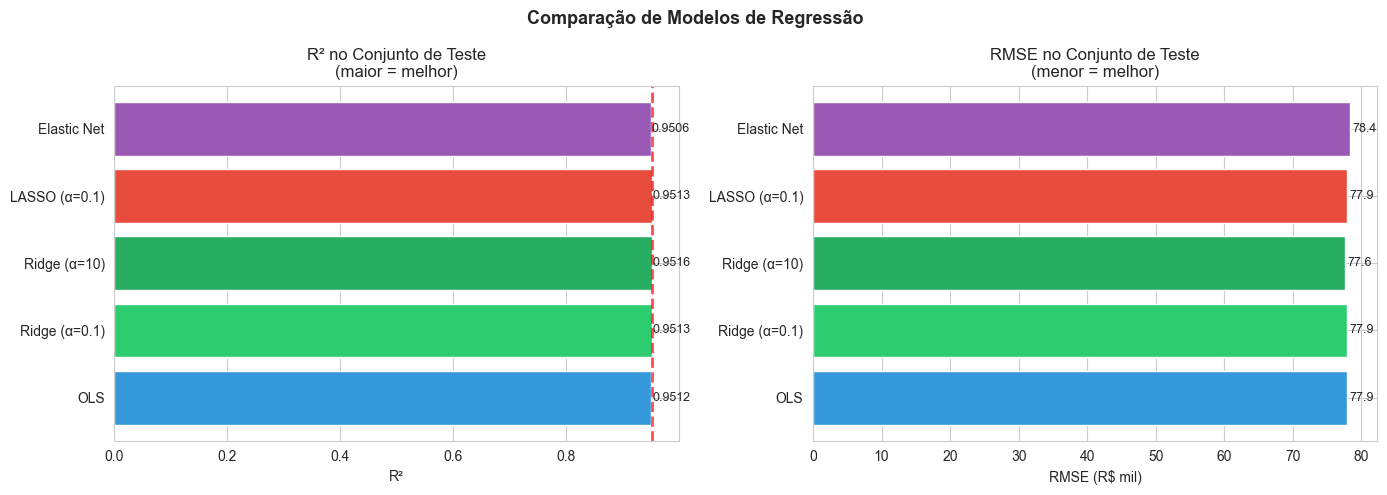

In [4]:
print("=" * 55)
print("🏆 COMPARAÇÃO FINAL DE TODOS OS MODELOS")
print("=" * 55)

modelos_final = {
    'OLS': LinearRegression(),
    'Ridge (α=0.1)': Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=0.1))]),
    'Ridge (α=10)': Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=10))]),
    'LASSO (α=0.1)': Pipeline([('sc', StandardScaler()), ('m', Lasso(alpha=0.1))]),
    'Elastic Net': Pipeline([('sc', StandardScaler()), ('m', ElasticNet(alpha=0.1, l1_ratio=0.5))]),
}

resultados_final = []
for nome, modelo in modelos_final.items():
    modelo.fit(X_train, y_train)
    y_pred_f = modelo.predict(X_test)
    cv_scores = cross_val_score(modelo, X, y, cv=5, scoring='r2')
    resultados_final.append({
        'Modelo': nome,
        'R² Teste': round(r2_score(y_test, y_pred_f), 4),
        'RMSE Teste': round(np.sqrt(mean_squared_error(y_test, y_pred_f)), 1),
        'MAE Teste': round(mean_absolute_error(y_test, y_pred_f), 1),
        'R² CV (média)': round(cv_scores.mean(), 4),
        'R² CV (dp)': round(cv_scores.std(), 4),
    })

df_final = pd.DataFrame(resultados_final).set_index('Modelo')
print("\n📊 Resultados (preço em R$ mil):")
display(df_final)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparação de Modelos de Regressão', fontsize=13, fontweight='bold')

cores = ['#3498db', '#2ecc71', '#27ae60', '#e74c3c', '#9b59b6']
axes[0].barh(df_final.index, df_final['R² Teste'], color=cores, edgecolor='white')
axes[0].set_xlabel('R²'); axes[0].set_title('R² no Conjunto de Teste\n(maior = melhor)')
axes[0].axvline(df_final['R² Teste'].max(), color='red', lw=2, linestyle='--', alpha=0.7)
for i, v in enumerate(df_final['R² Teste']):
    axes[0].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

axes[1].barh(df_final.index, df_final['RMSE Teste'], color=cores, edgecolor='white')
axes[1].set_xlabel('RMSE (R$ mil)'); axes[1].set_title('RMSE no Conjunto de Teste\n(menor = melhor)')
for i, v in enumerate(df_final['RMSE Teste']):
    axes[1].text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../imagens/04_comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Resumo, Pros e Contras e Exercícios

### 7.1 Tabela Comparativa

| Método | Pros | Contras | Quando Usar |
|--------|------|---------|-------------|
| **OLS** | Simples, interpretável, solução fechada | Sensível a multicolinearidade, overfitting com muitas features | Poucos preditores, relação linear clara |
| **Ridge (L2)** | Robusto à multicolinearidade, estável | Não faz seleção de variáveis, todos os coeficientes permanecem | Muitas features correlacionadas |
| **LASSO (L1)** | Seleção automática de variáveis, interpretável | Seleciona arbitrariamente 1 de features correlacionadas | Muitas features, suspeita de esparsidade |
| **Elastic Net** | Combina L1 e L2, lida com grupos de features | Dois hiperparâmetros para ajustar | Features em grupos com correlação interna |
| **GLM** | Adequado para dados não-gaussianos (Poisson, Binomial) | Requer especificação da família correta | Contagens, proporções, dados assimétricos |

### 7.2 Guia de Seleção de Modelo

```
Dados de regressão
    |
    ├── Resposta contínua gaussiana?
    │       |
    │       ├── Poucas features → OLS
    │       ├── Muitas features correlacionadas → Ridge
    │       ├── Suspeita de esparsidade → LASSO
    │       └── Grupos de features correlacionadas → Elastic Net
    |
    └── Resposta não-gaussiana?
            |
            ├── Contagens → GLM Poisson
            ├── Proporções/Binário → GLM Logístico
            └── Tempos → GLM Gamma / Weibull
```

### 7.3 Métricas de Avaliação

| Métrica | Fórmula | Interpretação | Quando Usar |
|---------|---------|---------------|-------------|
| **MSE** | $\frac{1}{n}\sum(y_i-\hat{y}_i)^2$ | Penaliza outliers fortemente | Quando erros grandes são críticos |
| **RMSE** | $\sqrt{MSE}$ | Na mesma escala da resposta | Interpretação direta em unidades |
| **MAE** | $\frac{1}{n}\sum|y_i-\hat{y}_i|$ | Robusto a outliers | Quando outliers são esperados |
| **R²** | $1-\frac{SS_{res}}{SS_{tot}}$ | % variância explicada (0-1) | Comparação entre modelos |

---

## 8. Exercícios Propostos

### Exercício 1 — Seleção de Hiperparâmetro com Cross-Validation
Utilize `RidgeCV` e `LassoCV` para encontrar automaticamente o melhor valor de `alpha` via validação cruzada. Compare o alpha ótimo de cada método e interprete: por que eles geralmente diferem? Plote o RMSE de validação em função de `log(alpha)`.

**Dica:** `RidgeCV(alphas=np.logspace(-3, 4, 100), cv=10).fit(X_train_sc, y_train)`

### Exercício 2 — Análise de Multicolinearidade com VIF
Adicione ao dataset original duas features artificialmente correlacionadas (ex: `area_m2 = area * 10.764` e `preco_por_m2 = preco_mil / area`). Calcule o Variance Inflation Factor (VIF) de cada feature antes e depois de aplicar Ridge e LASSO. Observe como a regularização lida com multicolinearidade.

**Dica:** `from statsmodels.stats.outliers_influence import variance_inflation_factor`

### Exercício 3 — GLM para Dados de Proporção
Simule um dataset de inadimplência bancária (variável resposta: taxa de inadimplência entre 0 e 1) e ajuste um GLM com família `Beta` ou `Binomial` usando `statsmodels`. Compare os coeficientes com uma Regressão Linear padrão (OLS) e discuta: por que o OLS é inapropriado para respostas limitadas ao intervalo [0,1]? Plote os resíduos deviance vs valores ajustados.

**Dica:** Utilize `GLM(y, X, family=families.Binomial()).fit()` com uma resposta proporcional.